
=============================================================
#Convolución Sobel 3x3 + Max Pooling 2x2 sobre imagen de gato
##  Autor: Alfredo Diaz

## Descripción:
    1. Carga la imagen y la convierte a escala de grises
    2. Aplica los filtros Sobel Gx y Gy (detectan bordes)
    3. Combina ambos en magnitud de gradiente
    4. Aplica Max Pooling 2x2 sobre el resultado
    5. Muestra TODOS los mapas intermedios
    6. Imprime conclusiones detalladas


In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import convolve
import os, sys

In [2]:
!curl -O https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/gato.JPG

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23446  100 23446    0     0   106k      0 --:--:-- --:--:-- --:--:--  106k


In [3]:
# ─── CONFIGURACIÓN ──────────────────────────────────────────
# Use a direct link to the image to avoid 403 errors from thumbnail URLs
IMAGE_PATH = "gato.JPG"
OUTPUT_PATH = "resultado_cnn.png"
POOL_SIZE   = 2                  # Tamaño del Max Pooling
print(f"Configuration set: IMAGE_PATH = {IMAGE_PATH}")

Configuration set: IMAGE_PATH = gato.JPG


In [4]:

# ─── 1. CARGAR IMAGEN ───────────────────────────────────────
print("=" * 60)
print("  CONVOLUCIÓN SOBEL + MAX POOLING — CNN VISUAL")
print("=" * 60)

if not os.path.exists(IMAGE_PATH):
    print(f"\n⚠  No se encontró '{IMAGE_PATH}'.")
    print("   Coloca una imagen llamada 'cat.jpg' en la misma carpeta.")
    sys.exit(1)

img_color = Image.open(IMAGE_PATH).convert("RGB")
img_gray  = img_color.convert("L")          # Escala de grises [0–255]

# Redimensionar a 256x256 para que sea manejable
img_color = img_color.resize((256, 256), Image.LANCZOS)
img_gray  = img_gray.resize((256, 256), Image.LANCZOS)



  CONVOLUCIÓN SOBEL + MAX POOLING — CNN VISUAL


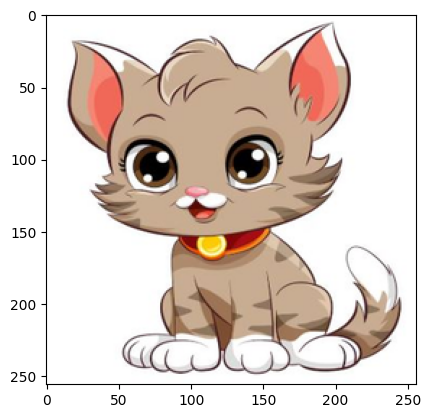

In [5]:
plt.imshow(img_color)
plt.show()

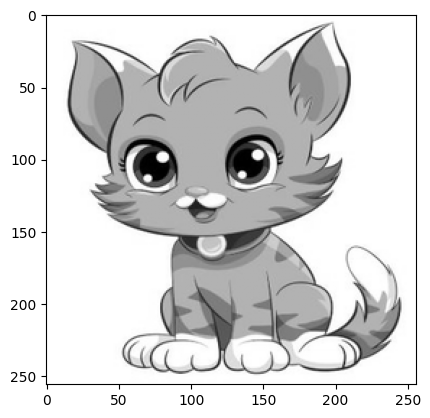

In [6]:
plt.imshow(img_gray, cmap="gray")
plt.show()

In [7]:
img_array  = np.array(img_color, dtype=np.float32)   # (256,256,3)
gray_array = np.array(img_gray,  dtype=np.float32)   # (256,256)

print(f"\n  Imagen cargada: {IMAGE_PATH}")
print(f"  Tamaño:         {gray_array.shape[1]} x {gray_array.shape[0]} px")
print(f"  Canales:        RGB → convertida a escala de grises")


  Imagen cargada: gato.JPG
  Tamaño:         256 x 256 px
  Canales:        RGB → convertida a escala de grises


In [8]:
import matplotlib.pyplot as plt

# ─── 2. KERNELS SOBEL ───────────────────────────────────────
# Sobel Gx: detecta bordes verticales (cambios horizontales de intensidad)
Gx = np.array([[-1,  0,  1],
               [-2,  0,  2],
               [-1,  0,  1]], dtype=np.float32)

# Sobel Gy: detecta bordes horizontales (cambios verticales de intensidad)
Gy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float32)

print("\n  Kernels Sobel:")
print(f"  Gx (bordes verticales):\n{Gx}\n")
print(f"  Gy (bordes horizontales):\n{Gy}")


  Kernels Sobel:
  Gx (bordes verticales):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

  Gy (bordes horizontales):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


In [9]:

# ─── 3. CONVOLUCIÓN ─────────────────────────────────────────
# Aplicar cada kernel sobre la imagen en escala de grises
conv_gx = convolve(gray_array, Gx)   # Respuesta horizontal
conv_gy = convolve(gray_array, Gy)   # Respuesta vertical

# Magnitud del gradiente: combina Gx y Gy
magnitude = np.sqrt(conv_gx**2 + conv_gy**2)

# Normalizar a [0, 255] para visualización
def normalize(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return arr.astype(np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)

gx_norm  = normalize(conv_gx)
gy_norm  = normalize(conv_gy)
mag_norm = normalize(magnitude)

print(f"\n  Convolución completada:")
print(f"  Gx  — min: {conv_gx.min():.1f}  max: {conv_gx.max():.1f}")
print(f"  Gy  — min: {conv_gy.min():.1f}  max: {conv_gy.max():.1f}")
print(f"  |G| — min: {magnitude.min():.1f}  max: {magnitude.max():.1f}")


  Convolución completada:
  Gx  — min: -1008.0  max: 1012.0
  Gy  — min: -1014.0  max: 978.0
  |G| — min: 0.0  max: 1025.5


In [10]:

# ─── 4. MAX POOLING 2x2 ─────────────────────────────────────
def max_pooling(arr, pool=2):
    """
    Max Pooling manual con stride = pool.
    Recorre el array en ventanas de (pool x pool) y toma el máximo.
    """
    h, w = arr.shape
    out_h = h // pool
    out_w = w // pool
    result = np.zeros((out_h, out_w), dtype=arr.dtype)
    for i in range(out_h):
        for j in range(out_w):
            region = arr[i*pool:(i+1)*pool, j*pool:(j+1)*pool]
            result[i, j] = region.max()
    return result

pooled_gx  = max_pooling(gx_norm,  POOL_SIZE)
pooled_gy  = max_pooling(gy_norm,  POOL_SIZE)
pooled_mag = max_pooling(mag_norm, POOL_SIZE)

print(f"\n  Max Pooling {POOL_SIZE}×{POOL_SIZE} aplicado:")
print(f"  Antes: {mag_norm.shape}  →  Después: {pooled_mag.shape}")
print(f"  Reducción: {mag_norm.size} píxeles  →  {pooled_mag.size} valores")
print(f"  Factor de compresión: {mag_norm.size / pooled_mag.size:.1f}x")


  Max Pooling 2×2 aplicado:
  Antes: (256, 256)  →  Después: (128, 128)
  Reducción: 65536 píxeles  →  16384 valores
  Factor de compresión: 4.0x



  Imagen guardada → resultado_cnn.png


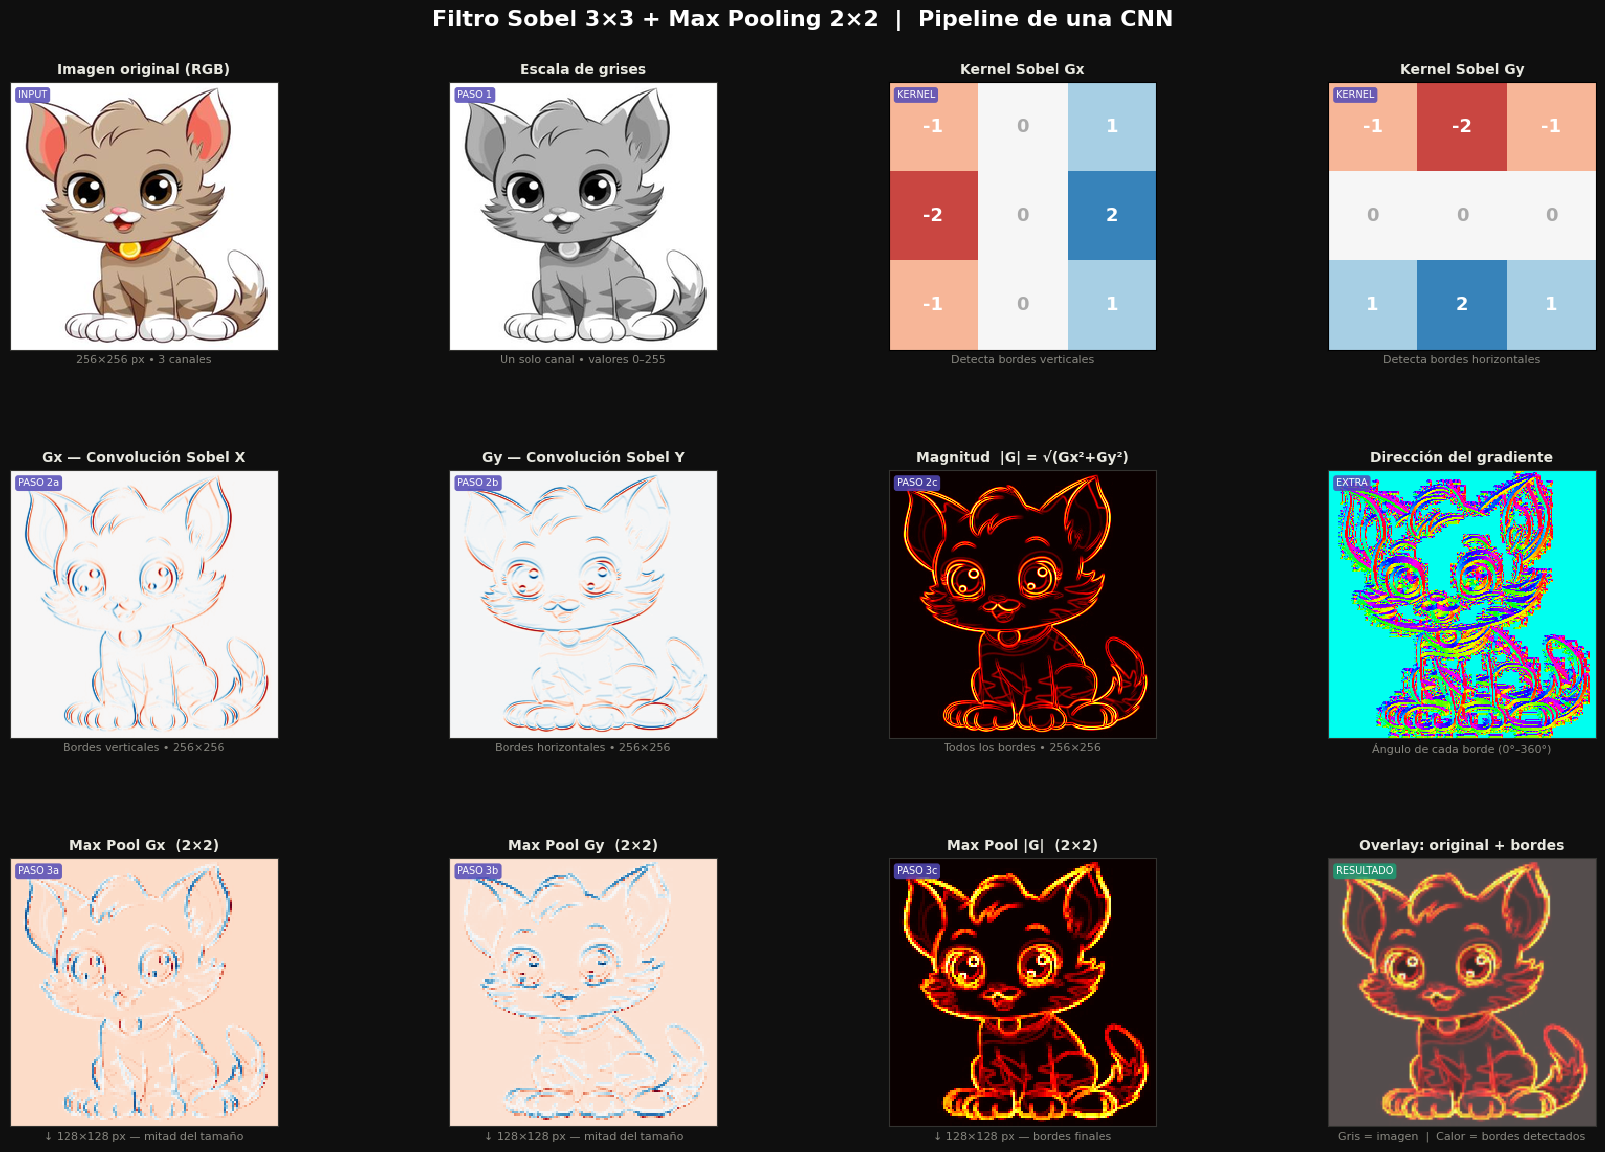

In [11]:

# ─── 5. VISUALIZACIÓN COMPLETA ──────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor="#0f0f0f")
fig.suptitle(
    "Filtro Sobel 3×3 + Max Pooling 2×2  |  Pipeline de una CNN",
    fontsize=16, fontweight="bold", color="white", y=0.98
)

gs = gridspec.GridSpec(3, 4, figure=fig,
                       hspace=0.45, wspace=0.3,
                       left=0.04, right=0.96,
                       top=0.92, bottom=0.05)

# ── Helpers ──────────────────────────────────────────
TITLE_STYLE  = dict(fontsize=10, fontweight="bold", color="#E8E8E0", pad=6)
SUB_STYLE    = dict(fontsize=8,  color="#888780")
BADGE_PROPS  = dict(boxstyle="round,pad=0.3", facecolor="#534AB7", alpha=0.85, edgecolor="none")

def add_axes(gs_slot, img, cmap, title, subtitle, badge=None):
    ax = fig.add_subplot(gs_slot)
    ax.imshow(img, cmap=cmap, interpolation="nearest")
    ax.set_title(title, **TITLE_STYLE)
    ax.set_xlabel(subtitle, **SUB_STYLE)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#333330")
    ax.set_facecolor("#1a1a18")
    if badge:
        ax.text(0.03, 0.97, badge, transform=ax.transAxes,
                fontsize=7, color="white", va="top",
                bbox=BADGE_PROPS)
    return ax

# Fila 0 — Inputs y kernels
add_axes(gs[0, 0], img_color.resize((256,256)), None,
         "Imagen original (RGB)",
         f"256×256 px • 3 canales", badge="INPUT")

add_axes(gs[0, 1], gray_array, "gray",
         "Escala de grises",
         "Un solo canal • valores 0–255", badge="PASO 1")

# Mostrar los dos kernels como imágenes
ax_gx_k = fig.add_subplot(gs[0, 2])
im = ax_gx_k.imshow(Gx, cmap="RdBu", vmin=-3, vmax=3, interpolation="nearest")
ax_gx_k.set_title("Kernel Sobel Gx", **TITLE_STYLE)
ax_gx_k.set_xlabel("Detecta bordes verticales", **SUB_STYLE)
for i in range(3):
    for j in range(3):
        ax_gx_k.text(j, i, f"{int(Gx[i,j])}", ha="center", va="center",
                     fontsize=13, fontweight="bold",
                     color="white" if abs(Gx[i,j]) > 0.5 else "#aaa")
ax_gx_k.set_xticks([]); ax_gx_k.set_yticks([])
ax_gx_k.text(0.03, 0.97, "KERNEL", transform=ax_gx_k.transAxes,
             fontsize=7, color="white", va="top", bbox=BADGE_PROPS)

ax_gy_k = fig.add_subplot(gs[0, 3])
ax_gy_k.imshow(Gy, cmap="RdBu", vmin=-3, vmax=3, interpolation="nearest")
ax_gy_k.set_title("Kernel Sobel Gy", **TITLE_STYLE)
ax_gy_k.set_xlabel("Detecta bordes horizontales", **SUB_STYLE)
for i in range(3):
    for j in range(3):
        ax_gy_k.text(j, i, f"{int(Gy[i,j])}", ha="center", va="center",
                     fontsize=13, fontweight="bold",
                     color="white" if abs(Gy[i,j]) > 0.5 else "#aaa")
ax_gy_k.set_xticks([]); ax_gy_k.set_yticks([])
ax_gy_k.text(0.03, 0.97, "KERNEL", transform=ax_gy_k.transAxes,
             fontsize=7, color="white", va="top", bbox=BADGE_PROPS)

# Fila 1 — Resultados de convolución
add_axes(gs[1, 0], gx_norm, "RdBu",
         "Gx — Convolución Sobel X",
         f"Bordes verticales • {gx_norm.shape[1]}×{gx_norm.shape[0]}", badge="PASO 2a")

add_axes(gs[1, 1], gy_norm, "RdBu",
         "Gy — Convolución Sobel Y",
         f"Bordes horizontales • {gy_norm.shape[1]}×{gy_norm.shape[0]}", badge="PASO 2b")

add_axes(gs[1, 2], mag_norm, "hot",
         "Magnitud  |G| = √(Gx²+Gy²)",
         f"Todos los bordes • {mag_norm.shape[1]}×{mag_norm.shape[0]}", badge="PASO 2c")

# Mapa de dirección de borde (opcional, interesante)
direction = np.arctan2(conv_gy, conv_gx) * 180 / np.pi
add_axes(gs[1, 3], direction, "hsv",
         "Dirección del gradiente",
         "Ángulo de cada borde (0°–360°)", badge="EXTRA")

# Fila 2 — Max Pooling
add_axes(gs[2, 0], pooled_gx, "RdBu",
         "Max Pool Gx  (2×2)",
         f"↓ {pooled_gx.shape[1]}×{pooled_gx.shape[0]} px — mitad del tamaño", badge="PASO 3a")

add_axes(gs[2, 1], pooled_gy, "RdBu",
         "Max Pool Gy  (2×2)",
         f"↓ {pooled_gy.shape[1]}×{pooled_gy.shape[0]} px — mitad del tamaño", badge="PASO 3b")

add_axes(gs[2, 2], pooled_mag, "hot",
         "Max Pool |G|  (2×2)",
         f"↓ {pooled_mag.shape[1]}×{pooled_mag.shape[0]} px — bordes finales", badge="PASO 3c")

# Comparación original vs resultado final (overlay)
ax_comp = fig.add_subplot(gs[2, 3])
ax_comp.imshow(gray_array, cmap="gray", alpha=0.5,
               extent=[0, pooled_mag.shape[1], pooled_mag.shape[0], 0])
ax_comp.imshow(pooled_mag, cmap="hot", alpha=0.7,
               extent=[0, pooled_mag.shape[1], pooled_mag.shape[0], 0])
ax_comp.set_title("Overlay: original + bordes", **TITLE_STYLE)
ax_comp.set_xlabel("Gris = imagen  |  Calor = bordes detectados", **SUB_STYLE)
ax_comp.set_xticks([]); ax_comp.set_yticks([])
ax_comp.text(0.03, 0.97, "RESULTADO", transform=ax_comp.transAxes,
             fontsize=7, color="white", va="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#1D9E75",
                       alpha=0.85, edgecolor="none"))
for spine in ax_comp.spines.values():
    spine.set_edgecolor("#333330")

plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight",
            facecolor="#0f0f0f", edgecolor="none")
print(f"\n  Imagen guardada → {OUTPUT_PATH}")

In [12]:


# ─── 6. CONCLUSIONES ────────────────────────────────────────
print("\n" + "=" * 60)
print("  CONCLUSIONES Y ANÁLISIS")
print("=" * 60)

pct_bright = (mag_norm > 128).sum() / mag_norm.size * 100
pct_pool   = (pooled_mag > 128).sum() / pooled_mag.size * 100

print(f"""
┌─ QUÉ HACE EL FILTRO SOBEL 3×3 ─────────────────────────────┐

  El filtro Sobel es un operador de detección de bordes. Usa
  dos kernels 3×3 que calculan la DERIVADA PARCIAL de la imagen:

  • Gx detecta BORDES VERTICALES: responde cuando hay un cambio
    brusco de intensidad de izquierda a derecha (columnas).
    Ejemplo: el contorno de la oreja del gato vista de frente.

  • Gy detecta BORDES HORIZONTALES: responde cuando el cambio
    ocurre de arriba a abajo (filas).
    Ejemplo: el límite entre la frente y el fondo.

  • |G| = √(Gx² + Gy²) es la MAGNITUD total del gradiente.
    Un píxel brillante en este mapa = borde fuerte en cualquier
    dirección. Así es como una CNN "ve" los contornos del objeto.

  Píxeles con borde fuerte (>50% brillo): {pct_bright:.1f}% de la imagen
  → La imagen tiene {"bastantes" if pct_bright > 15 else "pocos"} bordes definidos.

└──────────────────────────────────────────────────────────────┘

┌─ QUÉ HACE EL MAX POOLING 2×2 ──────────────────────────────┐

  Max Pooling divide el mapa de características en ventanas de
  2×2 píxeles y conserva SOLO EL VALOR MÁXIMO de cada ventana.

  • REDUCE el tamaño a la mitad en cada dimensión:
    {mag_norm.shape[0]}×{mag_norm.shape[1]}  →  {pooled_mag.shape[0]}×{pooled_mag.shape[1]} píxeles
    ({mag_norm.size:,} valores  →  {pooled_mag.size:,} valores,  {mag_norm.size/pooled_mag.size:.0f}× menos datos)

  • CONSERVA los bordes más fuertes (el máximo de cada región),
    descartando ruido y detalles irrelevantes.

  • Hace la red INVARIANTE A PEQUEÑOS DESPLAZAMIENTOS:
    si un borde se mueve 1 píxel, el máximo de la ventana
    probablemente no cambia → la CNN sigue reconociendo el gato.

  Bordes fuertes conservados tras pooling: {pct_pool:.1f}%

└──────────────────────────────────────────────────────────────┘

┌─ PARA QUÉ SIRVE TODO ESTO EN UNA CNN ──────────────────────┐

  En una Red Neuronal Convolucional este proceso se repite
  muchas veces con distintos filtros:

  1. Conv capa 1 → bordes simples (como Sobel)
  2. Pool capa 1 → compresión espacial
  3. Conv capa 2 → texturas (combinación de bordes)
  4. Pool capa 2 → más compresión
  5. Conv capa N → partes de objetos, formas complejas
  6. Flatten + Dense → decisión final ("es un gato")

  Los filtros NO se diseñan a mano como Sobel — se APRENDEN
  automáticamente durante el entrenamiento con backpropagation.
  Sobel es simplemente un ejemplo didáctico de lo que ocurre
  en la primera capa de una CNN entrenada en imágenes.

└──────────────────────────────────────────────────────────────┘
""")

plt.show()
print("  ¡Listo! Revisa el archivo:", OUTPUT_PATH)


  CONCLUSIONES Y ANÁLISIS

┌─ QUÉ HACE EL FILTRO SOBEL 3×3 ─────────────────────────────┐

  El filtro Sobel es un operador de detección de bordes. Usa
  dos kernels 3×3 que calculan la DERIVADA PARCIAL de la imagen:

  • Gx detecta BORDES VERTICALES: responde cuando hay un cambio
    brusco de intensidad de izquierda a derecha (columnas).
    Ejemplo: el contorno de la oreja del gato vista de frente.

  • Gy detecta BORDES HORIZONTALES: responde cuando el cambio
    ocurre de arriba a abajo (filas).
    Ejemplo: el límite entre la frente y el fondo.

  • |G| = √(Gx² + Gy²) es la MAGNITUD total del gradiente.
    Un píxel brillante en este mapa = borde fuerte en cualquier
    dirección. Así es como una CNN "ve" los contornos del objeto.

  Píxeles con borde fuerte (>50% brillo): 4.4% de la imagen
  → La imagen tiene pocos bordes definidos.

└──────────────────────────────────────────────────────────────┘

┌─ QUÉ HACE EL MAX POOLING 2×2 ──────────────────────────────┐

  Max Pooling di